In [2]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["axes.grid"] = True

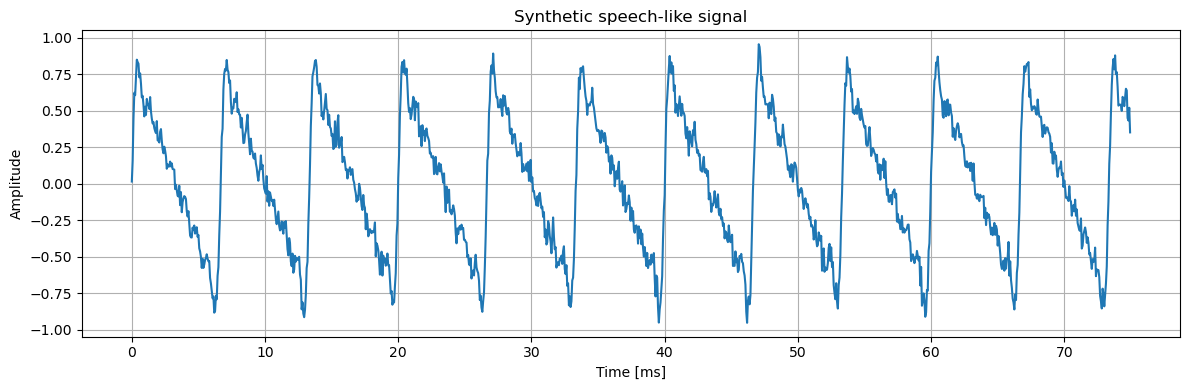

In [3]:
# Synthetic speech-like signal
rng = np.random.default_rng(42)
fs = 16_000
duration = 1.0

t = np.arange(0, duration, 1 / fs)
f0 = 150.0

# Fundamental + harmonics with decreasing amplitude
x = np.zeros_like(t)
for k in range(1, 8):
    x += np.sin(2 * np.pi * f0 * k * t) / k

# Add small noise and normalise
x += 0.1 * rng.standard_normal(t.shape)
x = x / np.max(np.abs(x))

plt.figure(figsize=(12, 4))
plt.plot(t[:1200] * 1000, x[:1200])
plt.title("Synthetic speech-like signal")
plt.xlabel("Time [ms]")
plt.ylabel("Amplitude")
plt.tight_layout()
plt.show()

## MFCC Pipeline

The **Mel-Frequency Cepstral Coefficient (MFCC)** pipeline converts an audio signal into compact features that describe the spectral shape of speech or sound.

### 1. Pre-emphasis

Apply a first-order high-pass filter:

$y[n] = x[n] - \alpha x[n-1]$

where typically:

$\alpha = 0.97$

This boosts high-frequency components that are naturally attenuated by the vocal tract.

### 2. Framing

The audio signal is split into short overlapping frames.

Typical values:

- Frame length: **25 ms**
- Hop size: **10 ms**

This is done because speech is approximately stationary over short time intervals.

### 3. Windowing

Each frame is multiplied by a window function, usually a **Hamming window**.

This reduces **spectral leakage** before applying the FFT.

### 4. FFT

Compute the **Fast Fourier Transform (FFT)** of each windowed frame.

From the FFT, calculate the **power spectrum**.

### 5. Mel Filterbank

Apply a set of triangular filters spaced on the **mel scale** to the power spectrum.

This produces **mel-band energies**, which approximate how humans perceive frequency.

### 6. Log Compression

Take the logarithm of the mel-band energies.

The log operation:

- Compresses the dynamic range
- Converts multiplicative spectral effects into additive ones
- Better matches human loudness perception

### 7. DCT

Apply the **Discrete Cosine Transform (DCT)** to the log-mel energies.

The DCT:

- Decorrelates neighbouring mel bands
- Compacts most of the information into the first few coefficients

Usually, the first **13 coefficients** are kept:

$\text{MFCC-0 to MFCC-12}$

![MFCC Pipeline](mfcc_pipeline.svg)

In [4]:
# Step 1: Pre-emphasis
alpha = 0.97
x_pre = np.concatenate([[x[0]], x[1:] - alpha * x[:-1]])  # Start till end of signal - one sample before end -1 is to the end

# Step 2: Framing
frame_len = int(0.025 * fs)   # 25 ms
hop_len = int(0.010 * fs)     # 10 ms
n_frames = 1 + (len(x_pre) - frame_len) // hop_len

frames = np.zeros((n_frames, frame_len))
for i in range(n_frames):
    start = i * hop_len
    frames[i] = x_pre[start:start + frame_len]

# Step 3: Hamming window
window = np.hamming(frame_len)
windowed_frames = frames * window

# Step 4: FFT and power spectrum
n_fft = 512
spectra = np.fft.rfft(windowed_frames, n=n_fft)
power_spectra = (np.abs(spectra) ** 2) / n_fft

print("Frames shape:", frames.shape)
print("Power spectra shape:", power_spectra.shape)

Frames shape: (98, 400)
Power spectra shape: (98, 257)


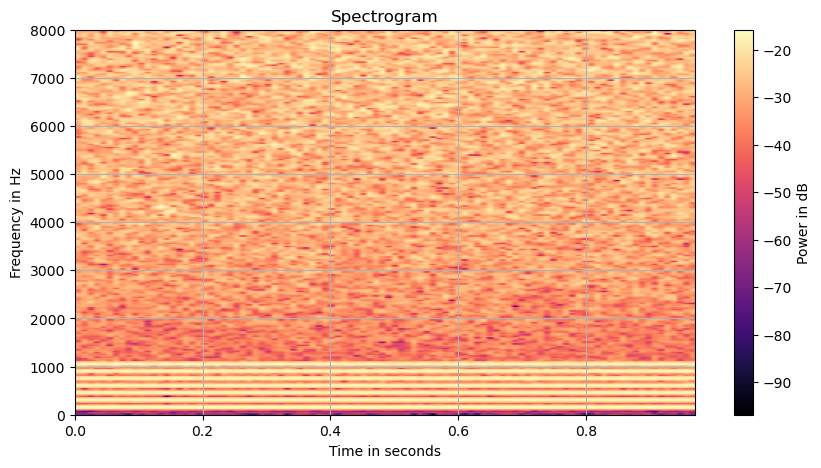

In [7]:
# Convert power to dB for better visualization
power_db = 10 * np.log10(power_spectra + 1e-10)
times = np.arange(n_frames) * hop_len / fs
freqs = np.fft.rfftfreq(n_fft, d=1/fs)
plt.figure(figsize=(10, 5))
plt.imshow(
    power_db.T,
    origin="lower",
    aspect="auto",
    cmap="magma",
    extent=[times[0], times[-1], freqs[0], freqs[-1]]
)

plt.colorbar(label="Power in dB")
plt.xlabel("Time in seconds")
plt.ylabel("Frequency in Hz")
plt.title("Spectrogram")
plt.show()

* The spectrogram shows the frequency content of the signal over time. 
* The bright horizontal bands at lower frequencies indicate strong harmonic components. 
* Most of the useful energy is concentrated below around 1 kHz, while the higher-frequency region contains weaker energy/noise-like components. 
* This confirms that after framing, windowing and FFT, the signal can be represented as a time-frequency power distribution.

In [6]:
# Step 5: Mel filterbank
n_mels = 40
f_min = 0
f_max = fs / 2
n_freqs = n_fft // 2 + 1

def hz_to_mel(f):
    return 2595 * np.log10(1 + f / 700)

def mel_to_hz(m):
    return 700 * (10 ** (m / 2595) - 1)

mel_min = hz_to_mel(f_min)
mel_max = hz_to_mel(f_max)
mel_points = np.linspace(mel_min, mel_max, n_mels + 2)
hz_points = mel_to_hz(mel_points)

bin_points = np.floor((n_fft + 1) * hz_points / fs).astype(int)
filterbank = np.zeros((n_mels, n_freqs))

for m in range(1, n_mels + 1):
    left = bin_points[m - 1]
    center = bin_points[m]
    right = bin_points[m + 1]

    for k in range(left, center):
        if center != left:
            filterbank[m - 1, k] = (k - left) / (center - left)

    for k in range(center, right):
        if right != center:
            filterbank[m - 1, k] = (right - k) / (right - center)

mel_spectra = power_spectra @ filterbank.T
log_mel = np.log(mel_spectra + 1e-10)

print("Mel filterbank shape:", filterbank.shape)
print("Log-mel spectrogram shape:", log_mel.shape)

Mel filterbank shape: (40, 257)
Log-mel spectrogram shape: (98, 40)


![Mel filterbank](mel_filterbank.svg)

In [7]:
# Step 6: DCT type-II implemented manually
n_mfcc = 13
n_mel_channels = log_mel.shape[1]

dct_matrix = np.zeros((n_mfcc, n_mel_channels))
for i in range(n_mfcc):
    for j in range(n_mel_channels):
        dct_matrix[i, j] = np.cos(np.pi * i * (j + 0.5) / n_mel_channels)

mfccs = log_mel @ dct_matrix.T

print("MFCC shape:", mfccs.shape)

MFCC shape: (98, 13)


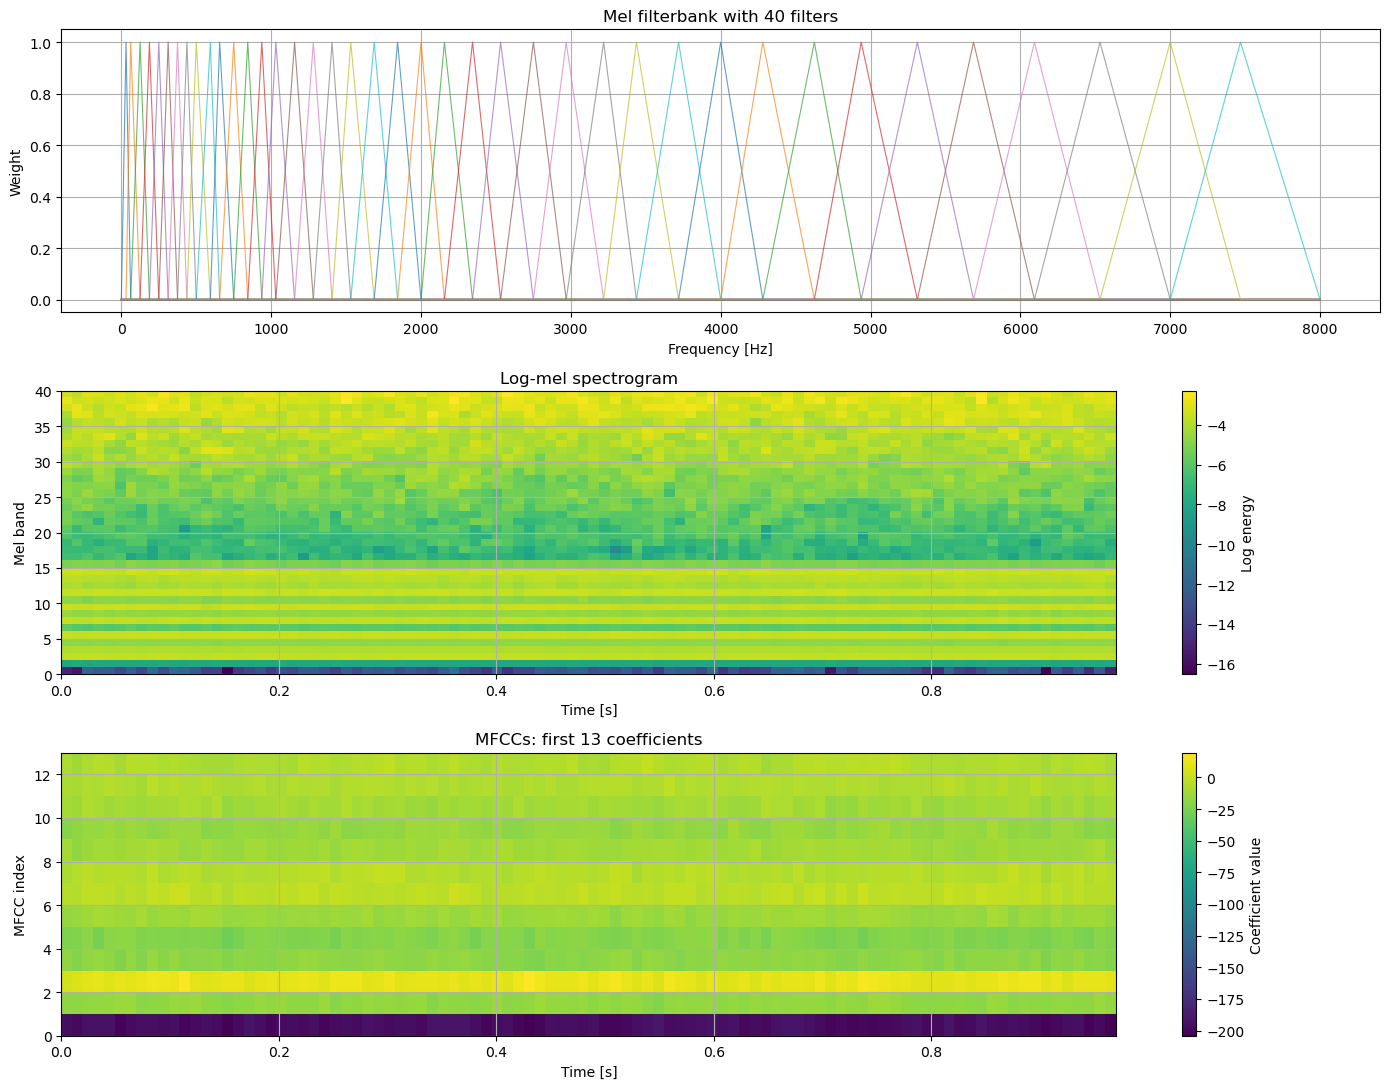

In [8]:
# Visualise mel filterbank, log-mel spectrogram, and MFCCs
freq_axis = np.linspace(0, fs / 2, n_freqs)
frame_times = np.arange(n_frames) * hop_len / fs

fig, axes = plt.subplots(3, 1, figsize=(14, 11))

for m in range(n_mels):
    axes[0].plot(freq_axis, filterbank[m], alpha=0.7, linewidth=0.8)
axes[0].set_title(f"Mel filterbank with {n_mels} filters")
axes[0].set_xlabel("Frequency [Hz]")
axes[0].set_ylabel("Weight")

im1 = axes[1].imshow(
    log_mel.T,
    aspect="auto",
    origin="lower",
    extent=[frame_times[0], frame_times[-1], 0, n_mels],
)
axes[1].set_title("Log-mel spectrogram")
axes[1].set_xlabel("Time [s]")
axes[1].set_ylabel("Mel band")
plt.colorbar(im1, ax=axes[1], label="Log energy")

im2 = axes[2].imshow(
    mfccs.T,
    aspect="auto",
    origin="lower",
    extent=[frame_times[0], frame_times[-1], 0, n_mfcc],
)
axes[2].set_title(f"MFCCs: first {n_mfcc} coefficients")
axes[2].set_xlabel("Time [s]")
axes[2].set_ylabel("MFCC index")
plt.colorbar(im2, ax=axes[2], label="Coefficient value")

plt.tight_layout()
plt.show()

In [ ]:
from matplotlib.animation import FuncAnimation
from IPython.display import HTML
import matplotlib.patches as patches

def animate_audio_pipeline():
    steps = [
        "Input\nSignal",
        "Pre-\nemphasis",
        "Framing",
        "Windowing",
        "FFT\nSpectrum",
        "Mel\nFilterbank",
        "Log-Mel",
        "MFCCs"
    ]

    fig, axes = plt.subplots(2, 1, figsize=(14, 8))
    ax_blocks, ax_plot = axes

    # -------------------------
    # Top: pipeline blocks
    # -------------------------
    ax_blocks.set_xlim(0, len(steps))
    ax_blocks.set_ylim(0, 1)
    ax_blocks.axis("off")

    block_patches = []

    for i, step in enumerate(steps):
        rect = patches.FancyBboxPatch(
            (i + 0.08, 0.3),
            0.82,
            0.4,
            boxstyle="round,pad=0.05",
            linewidth=1.5,
            facecolor="white",
            edgecolor="black"
        )
        ax_blocks.add_patch(rect)
        block_patches.append(rect)

        ax_blocks.text(
            i + 0.49,
            0.5,
            step,
            ha="center",
            va="center",
            fontsize=10
        )

        if i < len(steps) - 1:
            ax_blocks.annotate(
                "",
                xy=(i + 1.05, 0.5),
                xytext=(i + 0.9, 0.5),
                arrowprops=dict(arrowstyle="->", linewidth=1.5)
            )

    # -------------------------
    # Bottom: output plot
    # -------------------------
    def update(frame):
        ax_plot.clear()

        for i, rect in enumerate(block_patches):
            if i == frame:
                rect.set_facecolor("lightgray")
            else:
                rect.set_facecolor("white")

        if frame == 0:
            ax_plot.plot(t[:1200] * 1000, x[:1200])
            ax_plot.set_title("Input audio signal")
            ax_plot.set_xlabel("Time [ms]")
            ax_plot.set_ylabel("Amplitude")

        elif frame == 1:
            ax_plot.plot(t[:1200] * 1000, x_pre[:1200])
            ax_plot.set_title("After pre-emphasis")
            ax_plot.set_xlabel("Time [ms]")
            ax_plot.set_ylabel("Amplitude")

        elif frame == 2:
            frame_index = 10
            ax_plot.plot(frames[frame_index])
            ax_plot.set_title("One short-time frame")
            ax_plot.set_xlabel("Sample index")
            ax_plot.set_ylabel("Amplitude")

        elif frame == 3:
            frame_index = 10
            ax_plot.plot(windowed_frames[frame_index])
            ax_plot.set_title("Frame after Hamming window")
            ax_plot.set_xlabel("Sample index")
            ax_plot.set_ylabel("Amplitude")

        elif frame == 4:
            freq_axis = np.linspace(0, fs / 2, power_spectra.shape[1])
            ax_plot.plot(freq_axis, power_spectra[10])
            ax_plot.set_title("Power spectrum after FFT")
            ax_plot.set_xlabel("Frequency [Hz]")
            ax_plot.set_ylabel("Power")

        elif frame == 5:
            freq_axis = np.linspace(0, fs / 2, filterbank.shape[1])
            for m in range(filterbank.shape[0]):
                ax_plot.plot(freq_axis, filterbank[m], linewidth=0.8)
            ax_plot.set_title("Mel filterbank")
            ax_plot.set_xlabel("Frequency [Hz]")
            ax_plot.set_ylabel("Filter weight")

        elif frame == 6:
            ax_plot.imshow(log_mel.T, aspect="auto", origin="lower", cmap="viridis")
            ax_plot.set_title("Log-Mel spectrogram")
            ax_plot.set_xlabel("Frame index")
            ax_plot.set_ylabel("Mel band")

        elif frame == 7:
            ax_plot.imshow(mfccs.T, aspect="auto", origin="lower", cmap="viridis")
            ax_plot.set_title("MFCC features")
            ax_plot.set_xlabel("Frame index")
            ax_plot.set_ylabel("MFCC coefficient")

        fig.suptitle("Audio Signal Processing Pipeline", fontsize=16)
        plt.tight_layout()

    anim = FuncAnimation(
        fig,
        update,
        frames=len(steps),
        interval=1400,
        repeat=True
    )

    plt.close(fig)
    return anim

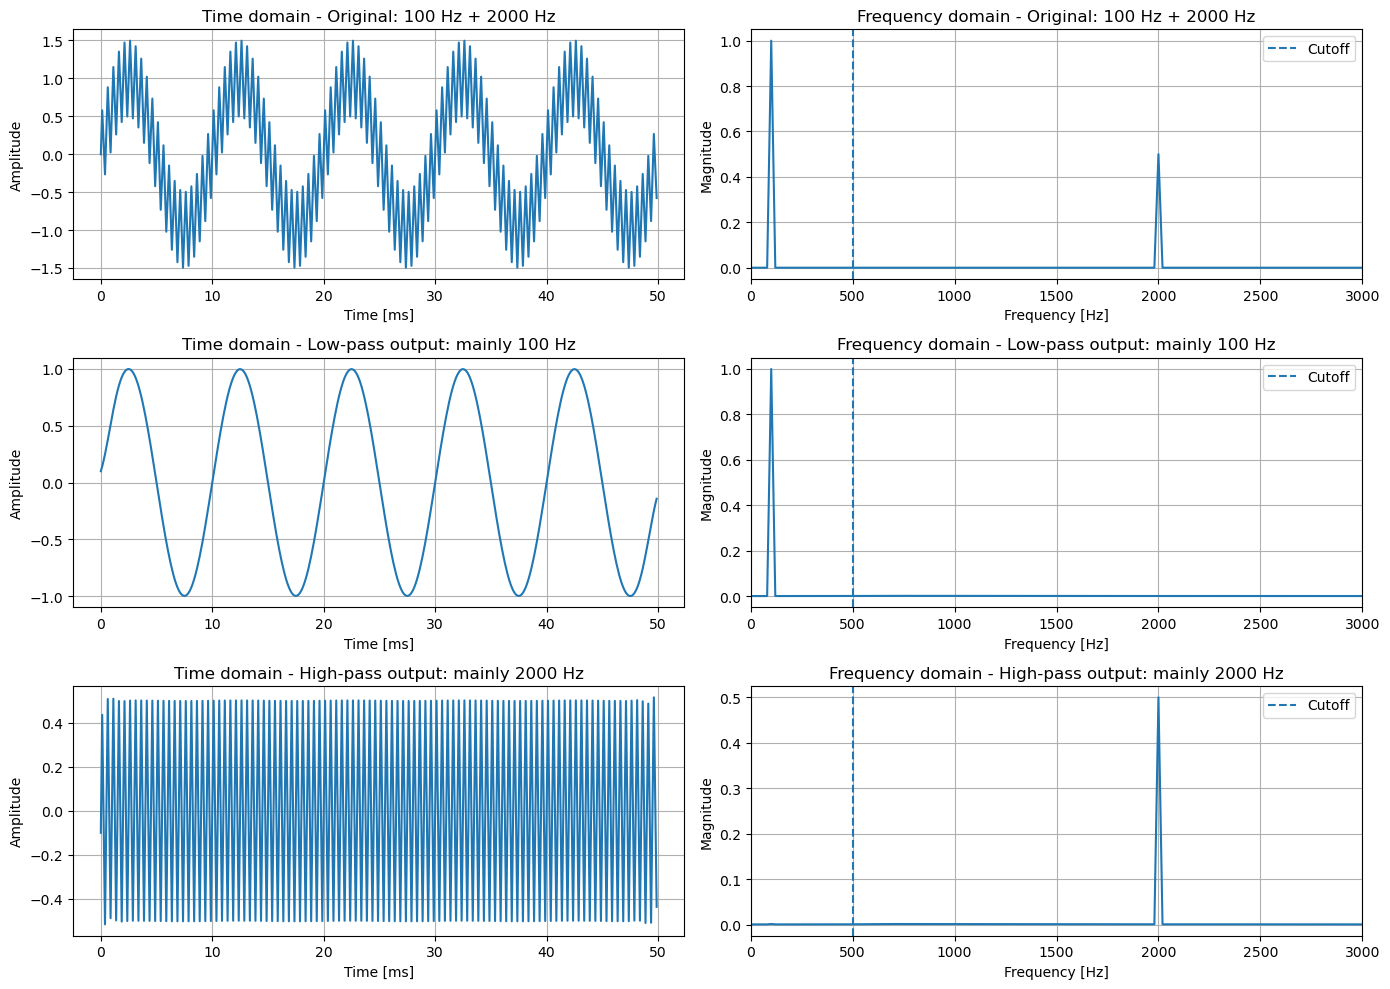

In [9]:

# ============================================================
# FIR Low-Pass and High-Pass Filtering Demo
# ============================================================
# This script creates a test signal containing two sine waves:
#   - 100 Hz  -> low-frequency component
#   - 2000 Hz -> high-frequency component
#
# A low-pass FIR filter is designed using the windowed-sinc method.
# The cutoff frequency is 500 Hz, so the filter should:
#   - keep the 100 Hz component
#   - reduce the 2000 Hz component
#
# The high-pass filter is created using spectral inversion:
#   high-pass = impulse - low-pass
#
# Finally, the script plots both time-domain signals and frequency spectra
# to show how the low-pass and high-pass filters separate the two components.
# ============================================================

fs = 8000
duration = 0.05

t = np.arange(0, duration, 1 / fs)

x_low = np.sin(2 * np.pi * 100 * t)
x_high = 0.5 * np.sin(2 * np.pi * 2000 * t)
x = x_low + x_high

# y[n] = b0*x[n] + b1*x[n-1] + b2*x[n-2] + ...

def fir_lowpass(cutoff_hz, fs, n_taps=51):
    """Design a low-pass FIR filter using the windowed-sinc method."""
    fc = cutoff_hz / fs
    n = np.arange(n_taps)
    mid = (n_taps - 1) / 2

    # Ideal low-pass impulse response
    h = np.sinc(2 * fc * (n - mid)) * 2 * fc

    # Windowing reduces sidelobes
    h *= np.hamming(n_taps)

    # Normalise DC gain to 1
    h /= np.sum(h)
    return h

def apply_fir(signal, h):
    return np.convolve(signal, h, mode="same")

def compute_spectrum(signal, fs):
    X = np.fft.rfft(signal)
    freqs = np.fft.rfftfreq(len(signal), d=1 / fs)
    mag = 2 * np.abs(X) / len(signal)
    return freqs, mag

cutoff_hz = 500
n_taps = 51

h_lp = fir_lowpass(cutoff_hz, fs, n_taps=n_taps)
x_lp = apply_fir(x, h_lp)

# High-pass filter by spectral inversion: delta - low-pass
delta = np.zeros(n_taps)
delta[n_taps // 2] = 1
h_hp = delta - h_lp
x_hp = apply_fir(x, h_hp)

fig, axes = plt.subplots(3, 2, figsize=(14, 10))

signals = [
    (x, "Original: 100 Hz + 2000 Hz"),
    (x_lp, "Low-pass output: mainly 100 Hz"),
    (x_hp, "High-pass output: mainly 2000 Hz"),
]

for row, (sig, title) in enumerate(signals):
    axes[row, 0].plot(t * 1000, sig)
    axes[row, 0].set_title("Time domain - " + title)
    axes[row, 0].set_xlabel("Time [ms]")
    axes[row, 0].set_ylabel("Amplitude")

    freqs, mag = compute_spectrum(sig, fs)
    axes[row, 1].plot(freqs, mag)
    axes[row, 1].axvline(cutoff_hz, linestyle="--", label="Cutoff")
    axes[row, 1].set_title("Frequency domain - " + title)
    axes[row, 1].set_xlabel("Frequency [Hz]")
    axes[row, 1].set_ylabel("Magnitude")
    axes[row, 1].set_xlim(0, 3000)
    axes[row, 1].legend()

plt.tight_layout()
plt.show()

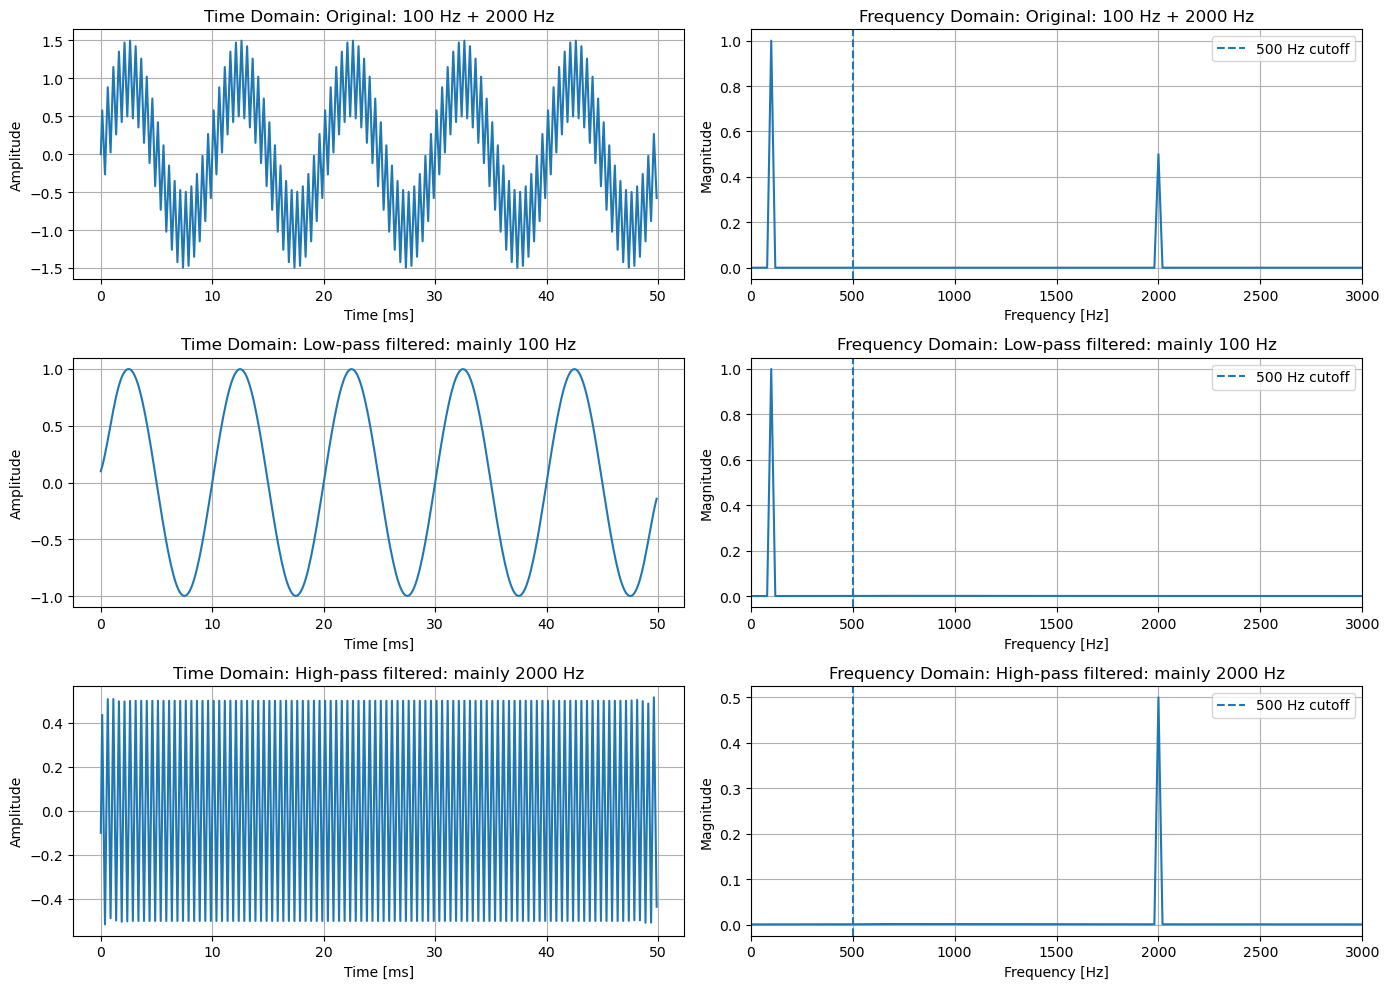

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import firwin, convolve

# ============================================================
# FIR Low-Pass and High-Pass Filtering Demo using scipy.firwin
# ============================================================
# This script creates a signal with two frequency components:
#   - 100 Hz  -> low-frequency component
#   - 2000 Hz -> high-frequency component
#
# A low-pass FIR filter is designed using scipy.signal.firwin.
# firwin internally uses the windowed-sinc method.
#
# The low-pass filter has a cutoff of 500 Hz:
#   - keeps 100 Hz
#   - reduces 2000 Hz
#
# A high-pass FIR filter is also designed directly using firwin.
#
# Finally, the script plots the time-domain signals and spectra
# to show how the FIR filters separate low and high frequencies.
# ============================================================

# Create test signal
fs = 8000
duration = 0.05
t = np.arange(0, duration, 1.0 / fs)

x_low = np.sin(2 * np.pi * 100 * t)
x_high = 0.5 * np.sin(2 * np.pi * 2000 * t)
x = x_low + x_high

# FIR filter design using built-in function
n_taps = 51
cutoff_hz = 500

h_lp = firwin(
    numtaps=n_taps,
    cutoff=cutoff_hz,
    fs=fs,
    window="hamming",
    pass_zero="lowpass"
)

h_hp = firwin(
    numtaps=n_taps,
    cutoff=cutoff_hz,
    fs=fs,
    window="hamming",
    pass_zero="highpass"
)

# Apply filters
x_lp = convolve(x, h_lp, mode="same")
x_hp = convolve(x, h_hp, mode="same")

# Compute spectrum
def compute_spectrum(signal, fs):
    X = np.fft.rfft(signal)
    freqs = np.fft.rfftfreq(len(signal), d=1.0 / fs)
    mag = np.abs(X) / len(signal) * 2
    return freqs, mag

# Plot
fig, axes = plt.subplots(3, 2, figsize=(14, 10))

signals = [
    (x, "Original: 100 Hz + 2000 Hz"),
    (x_lp, "Low-pass filtered: mainly 100 Hz"),
    (x_hp, "High-pass filtered: mainly 2000 Hz")
]

for i, (sig, title) in enumerate(signals):
    axes[i, 0].plot(t * 1000, sig)
    axes[i, 0].set_title("Time Domain: " + title)
    axes[i, 0].set_xlabel("Time [ms]")
    axes[i, 0].set_ylabel("Amplitude")
    axes[i, 0].grid(True)

    freqs, mag = compute_spectrum(sig, fs)
    axes[i, 1].plot(freqs, mag)
    axes[i, 1].axvline(cutoff_hz, linestyle="--", label="500 Hz cutoff") # Vertical line at cutoff frequency
    axes[i, 1].set_title("Frequency Domain: " + title)
    axes[i, 1].set_xlabel("Frequency [Hz]")
    axes[i, 1].set_ylabel("Magnitude")
    axes[i, 1].set_xlim(0, 3000)
    axes[i, 1].legend()
    axes[i, 1].grid(True)

plt.tight_layout()
plt.show()